# Stitching with compute backends

multiview-stitcher supports pluggable compute backends. The default backend
is **NumPy/SciPy** (CPU), but you can switch to a different backend such as **CuPy** (GPU) for
significant speedups on CUDA-capable hardware.

In this notebook, we present the basic usage of the backend functionality.
Additionally, we compare the performance and verify the correctness of different backends.

The backend feature currently supports these four functions:

| Function | Module | What it does |
|---|---|---|
| `transform_data()` | `transformation` | Affine transform on raw arrays |
| `get_blending_weights()` | `weights` | Cosine blending weights for fusion |
| `register()` | `registration` | Pairwise tile registration |
| `fuse()` | `fusion` | Full mosaic fusion pipeline |

**Requirements:** `multiview-stitcher`, `cupy` (e.g. `pip install cupy-cuda12x`),
optionally `cucim` for GPU-native phase cross-correlation.

---

### Cross-version benchmarking

This notebook also supports benchmarking the **original (PyPI) version** of
multiview-stitcher for comparison against the new backend-enabled version.

**Workflow:**

1. **Install the PyPI version** (`pip install multiview-stitcher`)
2. **Run this notebook** — it auto-detects the original version and benchmarks
   `get_blending_weights`, `register`, and `fuse` without any backend parameter.
   (`transform_data` is skipped as it doesn't exist in the original version.)
   Results are saved as JSON to the output directory.
3. **Install the dev version** (editable install from this repo)
4. **Run this notebook again** with your desired backend specs.
   New results are saved alongside the original results.
5. **View combined results** — the evaluation cell loads all JSON files from the
   output directory and plots original vs backend performance side by side.

Hardware x Backend Matrix

<table style="width: 100%; table-layout: fixed; border-collapse: collapse;">
  <thead>
    <tr>
      <th style="width: 16.66%; text-align: center;"></th>
      <th style="width: 16.66%; text-align: center;">array-api (numpy, cupy, dpnp)</th>
      <th style="width: 16.66%; text-align: center;">numpy-legacy</th>
      <th style="width: 16.66%; text-align: center;">cupy-legacy</th>
      <th style="width: 16.66%; text-align: center;">numba</th>
      <th style="width: 16.66%; text-align: center;">jax</th>
      <th style="width: 16.66%; text-align: center;">MLX</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: center;"><strong>CPU</strong></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>Nvidia GPU</strong></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>AMD GPU</strong></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>Intel GPU</strong></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>Google TPU</strong></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>Apple M-series</strong></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
    </tr>
  </tbody>
</table>

* also exists as cupy+numba combination

## 1. Setup

In [1]:
import json
import os
import time
import platform
import numpy as np
import dask

import multiview_stitcher
from multiview_stitcher import (
    fusion, msi_utils, registration, sample_data, weights,
)
from multiview_stitcher import spatial_image_utils as si_utils
from multiview_stitcher.io import METADATA_TRANSFORM_KEY

# ── Detect backend support ──
_HAS_BACKENDS = False
_HAS_BACKEND_PARAM = "backend" in fusion.fuse.__code__.co_varnames
_REGISTRY = {}

try:
    from multiview_stitcher.backends import get_backend, _REGISTRY
    from multiview_stitcher import param_utils
    from multiview_stitcher import transformation
    _HAS_BACKENDS = True
except ImportError:
    pass

# ── Detect numba toggling ──
_HAS_NUMBA_TOGGLE = hasattr(multiview_stitcher, "set_numba_acceleration")

print(f"multiview-stitcher version: {multiview_stitcher.__version__}")
print(f"Backend module available: {_HAS_BACKENDS}")
print(f"Backend parameter support: {_HAS_BACKEND_PARAM}")
print(f"Numba toggle: {_HAS_NUMBA_TOGGLE}")
if _REGISTRY:
    print(f"Registered backends: {list(_REGISTRY.keys())}")
print()

# --- CPU info (shared by all CPU backends) ---
cpu_name = platform.processor() or platform.machine()
try:
    with open("/proc/cpuinfo") as f:
        for line in f:
            if line.startswith("model name"):
                cpu_name = line.split(":", 1)[1].strip()
                break
except FileNotFoundError:
    pass

# --- Check each backend: package version and device info ---
if _REGISTRY:
    for name in _REGISTRY:
        print(f"Backend: {name!r}")

        if name in ("numpy", "numpy-legacy"):
            print(f"  Package: numpy {np.__version__}")
            print(f"  Device:  {cpu_name}")

        elif name in ("cupy", "cupy-legacy"):
            try:
                import cupy as cp
                print(f"  Package: cupy {cp.__version__}")
                runtime = "ROCm (HIP)" if cp.cuda.runtime.is_hip else "CUDA"
                print(f"  Runtime: {runtime}")
                for dev_id in range(cp.cuda.runtime.getDeviceCount()):
                    props = cp.cuda.runtime.getDeviceProperties(dev_id)
                    mem = cp.cuda.Device(dev_id).mem_info
                    print(f"  Device {dev_id}: {props['name'].decode()}, "
                          f"{mem[1] / 1e9:.1f} GB total, {mem[0] / 1e9:.1f} GB free")
            except Exception as e:
                print(f"  Not available: {e}")

        elif name == "dpnp":
            try:
                import dpnp
                print(f"  Package: dpnp {dpnp.__version__}")
                import dpctl
                for dev in dpctl.get_devices():
                    print(f"  Device:  {dev.name} ({dev.backend.name})")
            except Exception as e:
                print(f"  Not available: {e}")

        elif name == "numba":
            try:
                import numba
                print(f"  Package: numba {numba.__version__}")
                print(f"  Device:  {cpu_name}")
                print(f"  Threads: {numba.config.NUMBA_NUM_THREADS}")
            except Exception as e:
                print(f"  Not available: {e}")

        elif name == "jax":
            try:
                import jax
                print(f"  Package: jax {jax.__version__}")
                for dev in jax.devices():
                    if dev.platform == "cpu":
                        print(f"  Device:  {cpu_name} (jax cpu)")
                    else:
                        print(f"  Device:  {dev.device_kind} (jax {dev.platform})")
            except Exception as e:
                print(f"  Not available: {e}")

        elif name == "mlx":
            try:
                import mlx.core as mx
                print(f"  Package: mlx {mx.__version__}")
                print(f"  Device:  Apple Silicon (unified memory)")
            except Exception as e:
                print(f"  Not available: {e}")

        else:
            print(f"  (no device info available)")

        print()
else:
    print(f"Original mode (no backends module)")
    print(f"  CPU: {cpu_name}")
    print(f"  NumPy: {np.__version__}")

multiview-stitcher version: 0.1.49.dev0+g3d69a6c71.d20260401
Backend module available: True
Backend parameter support: True
Numba toggle: True
Registered backends: ['numpy', 'numpy-legacy']

Backend: 'numpy'
  Package: numpy 2.4.3
  Device:  Intel(R) Xeon(R) Gold 6130 CPU @ 2.10GHz

Backend: 'numpy-legacy'
  Package: numpy 2.4.3
  Device:  Intel(R) Xeon(R) Gold 6130 CPU @ 2.10GHz



## 2. Quick demo: using the backend parameter

Every backend-aware function accepts `backend="numpy"` (default) or
`backend="cupy"`. The API is otherwise identical.

In [ ]:
if not _HAS_BACKENDS:
    print("Quick demo requires the backends module (dev version).")
    print("Skipping demo — benchmark will use original mode.")
else:
    # Generate a small 2D dataset for the demo
    demo_sims = sample_data.generate_tiled_dataset(
        ndim=2, N_c=1, N_t=1, tile_size=50,
        tiles_x=2, tiles_y=2, tiles_z=1,
        overlap=10, spacing_x=1, spacing_y=1, spacing_z=1,
    )
    demo_sdims = si_utils.get_spatial_dims_from_sim(demo_sims[0])
    print(f"Demo tiles: {len(demo_sims)}, shape: {demo_sims[0].shape}")

    # --- transform_data ---
    sim = demo_sims[0].sel(t=demo_sims[0].coords["t"][0],
                            c=demo_sims[0].coords["c"][0]).astype(np.float32)
    output_props = {
        "spacing": {d: 1.0 for d in demo_sdims},
        "origin":  {d: 0.0 for d in demo_sdims},
        "shape":   {d: 50  for d in demo_sdims},
    }
    result = transformation.transform_data(
        np.asarray(sim.data),
        p=param_utils.identity_transform(len(demo_sdims)),
        input_spacing=si_utils.get_spacing_from_sim(sim, asarray=True),
        input_origin=si_utils.get_origin_from_sim(sim, asarray=True),
        output_stack_properties=output_props,
        spatial_dims=demo_sdims,
        backend="numpy",  # or "cupy"
    )
    print(f"transform_data  -> {type(result).__name__}, shape {result.shape}")

    # --- get_blending_weights ---
    source_bb = {
        "spacing": {d: 1.0 for d in demo_sdims},
        "origin":  {d: 0.0 for d in demo_sdims},
        "shape":   {d: 50  for d in demo_sdims},
    }
    w = weights.get_blending_weights(
        target_bb=output_props, source_bb=source_bb,
        affine=np.eye(len(demo_sdims) + 1),
        backend="numpy",  # or "cupy"
    )
    print(f"blending_weights -> {type(w).__name__}, shape {w.shape}")

    # --- register ---
    demo_msims = [msi_utils.get_msim_from_sim(s, scale_factors=[]) for s in demo_sims]
    params = registration.register(
        demo_msims,
        reg_channel_index=0,
        transform_key=METADATA_TRANSFORM_KEY,
        backend="numpy",  # or "cupy"
    )
    print(f"register        -> {len(params)} transforms")

    # --- fuse ---
    demo_sims_reg = [msi_utils.get_sim_from_msim(m) for m in demo_msims]
    fused = fusion.fuse(
        demo_sims_reg,
        transform_key=METADATA_TRANSFORM_KEY,
        backend="numpy",  # or "cupy"
    ).compute(scheduler="single-threaded")
    print(f"fuse            -> shape {fused.shape}, dtype {fused.dtype}")

## 3. Benchmark

We benchmark all four backend-aware functions independently across
configurable tile sizes, backends, and devices. Edit the configuration
variables below to control what gets benchmarked.

- **transform_data** and **get_blending_weights** are called directly on
  tile_size³ arrays (no dask overhead).
- **register** and **fuse** use a 3×3 tiled dataset (3D, 20% overlap).
- **fuse** reports per-chunk compute time *and* dask scheduling overhead
  separately, so the true GPU speedup is visible.

Results are stored as a JSON-serializable dictionary keyed by
(function, backend, device, tile_size) for flexible downstream analysis.

**Original mode:** When running with the original PyPI version (no backends
module), the notebook automatically switches to original mode. Only
`get_blending_weights`, `register`, and `fuse` are benchmarked (without
the `backend=` parameter). Results use `backend="original"` in the JSON
output and can be compared alongside backend results.

In [ ]:
# Papermill parameters — override these from the command line.
# Example: papermill ... -r TILE_SIZES '[50,100]' -p N_RUNS 3
TILE_SIZES = [50, 100, 200, 400, 800]
N_RUNS = 3
WARM_UP_RUNS = 1
MAX_WARM_UP_TIME = 30
OUTPUT_DIR = "benchmark_backends_results"
CHECK_CORRECTNESS = True


In [ ]:
# Coerce papermill parameters that arrive as strings
import ast as _ast
if isinstance(TILE_SIZES, str):
    TILE_SIZES = _ast.literal_eval(TILE_SIZES)
TILE_SIZES = [int(t) for t in TILE_SIZES]
N_RUNS = int(N_RUNS)
WARM_UP_RUNS = int(WARM_UP_RUNS)
MAX_WARM_UP_TIME = int(MAX_WARM_UP_TIME)
CHECK_CORRECTNESS = bool(CHECK_CORRECTNESS)


In [3]:
from datetime import datetime, timezone

# ── Configuration ─────────────────────────────────────────────────────
# When running with the original PyPI version (no backends module),
# set SPECS = ["original"]. When running with the dev version,
# use backend specs as before.

if _HAS_BACKENDS:
    from multiview_stitcher.backends import plan_benchmarks, run_benchmarks

    # # CPU
    # SPECS = [
    #     "numpy",          # ArrayAPI(numpy) — new unified path
    #     "numpy-legacy",   # original NumpyBackend
    #     "jax:cpu",        # JAX on CPU
    # ]

    # Nvidia GPU
    SPECS = [
        # "cupy",          # ArrayAPI(cupy) — new unified path
        # "cupy-legacy",   # original CupyBackend
        "jax:gpu",       # JAX (with jax[cuda] installed)
    ]

    # AMD GPU (ROCm)
    #
    # JAX on ROCm requires two workarounds (as of jax-rocm7-plugin 0.9.x):
    #
    #   1. HIP_VISIBLE_DEVICES — XLA's autotuner crashes (fatal hipError_t 98)
    #      on certain GCN architectures. When a system has multiple AMD GPUs
    #      with *different* architectures (e.g. gfx906 + gfx908), XLA cannot
    #      switch between them at runtime. We auto-detect the GPU with the
    #      newest architecture and restrict JAX to that single device.
    #
    #   2. XLA_FLAGS="--xla_gpu_autotune_level=0" — disables XLA's autotuner
    #      which tries to load a `RepeatBufferKernel` that is not compiled for
    #      older ROCm GPU targets. Without this flag the process aborts with a
    #      fatal C++ CHECK failure (not a catchable Python exception).
    #
    # See: https://github.com/ROCm/rocm-jax/issues/360
    # Canary: test_rocm_bug_xla_autotuner_repeat_buffer_kernel
    #
    # import os, subprocess, shutil

    # def _select_best_rocm_gpu():
    #     """Pick the newest-architecture AMD GPU and return its HIP device index."""
    #     try:
    #         out = subprocess.check_output(
    #             ["rocm-smi", "--showproductname"], text=True, stderr=subprocess.DEVNULL,
    #         )
    #     except (FileNotFoundError, subprocess.CalledProcessError):
    #         return None
    #     gpus = {}
    #     current_id = None
    #     for line in out.splitlines():
    #         stripped = line.strip()
    #         if stripped.startswith("GPU["):
    #             current_id = int(stripped.split("[")[1].split("]")[0])
    #         if current_id is not None and "GFX Version" in stripped:
    #             gpus[current_id] = stripped.split(":")[-1].strip()
    #     if not gpus:
    #         return None
    #     best = max(gpus, key=lambda k: gpus[k])
    #     print(f"ROCm GPUs detected: {gpus}")
    #     print(f"  -> selecting GPU {best} ({gpus[best]})")
    #     return best

    # _rocm_gpu = _select_best_rocm_gpu()
    # if _rocm_gpu is not None:
    #     os.environ["HIP_VISIBLE_DEVICES"] = str(_rocm_gpu)
    #     os.environ["XLA_FLAGS"] = os.environ.get("XLA_FLAGS", "") + " --xla_gpu_autotune_level=0"
    #     print(f"  -> HIP_VISIBLE_DEVICES={_rocm_gpu}")
    #     print(f"  -> XLA_FLAGS: --xla_gpu_autotune_level=0")

    # SPECS = [
    #     "cupy:gpu",          # ArrayAPI(cupy) — new unified path
    #     "cupy-legacy:gpu",   # original CupyBackend
    #     "jax:gpu",       # JAX (with jax[rocm] installed)
    # ]

    # # Intel GPU (dpnp) — use cupy-intel-dpnp devcontainer
    # SPECS = [
    #     "dpnp",           # ArrayAPI(dpnp) — Intel GPU via SYCL/Level Zero
    #     # "jax:xpu",        # JAX (with intel-extension-for-openxla)
    # ]

    # # Mac's M-Series GPU
    # SPECS = [
    #     "mlx",            # MLX (Apple Silicon unified memory)
    # ]

    # # TPU
    # SPECS = [
    #     "jax:tpu",        # JAX (with jax[tpu] installed)
    # ]

    FUNCTIONS = [
        "transform_data",
        "get_blending_weights",
        "register",
        "fuse",
    ]

    # Numba acceleration toggle:
    #   None          — use current global setting (one run per job)
    #   True          — only numba-enabled runs
    #   False         — only numba-disabled runs
    #   [True, False] — run each job twice: with and without numba
    NUMBA_ACCELERATION = [True, False]

else:
    # ── Original (PyPI) version — no backends module ──
    SPECS = ["original"]

    # transform_data is benchmarked via transform_sim (same affine math,
    # but wraps/unwraps SpatialImage instead of operating on raw arrays)
    FUNCTIONS = [
        "transform_data",
        "get_blending_weights",
        "register",
        "fuse",
    ]

    NUMBA_ACCELERATION = [None]

# Correctness checking: compare each backend's results against numpy
# reference. Per-iteration max_abs_diff is logged in the JSON output.

# Phase 1: plan what to benchmark
if _HAS_BACKENDS and "original" not in SPECS:
    plan = plan_benchmarks(
        specs=SPECS,
        tile_sizes=TILE_SIZES,
        functions=FUNCTIONS,
        numba_acceleration=NUMBA_ACCELERATION,
    )
else:
    plan = None
    print(f"\nOriginal mode benchmark plan:")
    print(f"  Tile sizes: {TILE_SIZES}")
    print(f"  Functions:  {FUNCTIONS}")
    print(f"  Output:     {OUTPUT_DIR}")

Skipped: [('jax:gpu', "Unknown backend 'jax' in spec 'jax:gpu'. Available: ['numpy', 'numpy-legacy']")]

Benchmark plan: 0 jobs across 0 groups
  Tile sizes: [50, 100, 200, 400, 800]
  Functions:  ['transform_data', 'get_blending_weights', 'register', 'fuse']
  Numba:      [True, False]
  Groups:



In [ ]:
import gc
import hashlib
import subprocess
import tempfile


def _gather_original_system_info():
    """Collect system information (standalone, no backends dependency)."""
    info = {
        "id": None,
        "platform": platform.platform(),
        "python": platform.python_version(),
        "multiview_stitcher": multiview_stitcher.__version__,
        "numpy": np.__version__,
        "cpu": cpu_name,
        "ram_gb": None,
        "gpus": [],
    }
    try:
        with open("/proc/meminfo") as f:
            for line in f:
                if line.startswith("MemTotal"):
                    info["ram_gb"] = round(int(line.split()[1]) / 1e6, 1)
                    break
    except FileNotFoundError:
        pass
    fp = hashlib.sha256(
        "|".join([info["cpu"], str(info.get("ram_gb", ""))]).encode()
    ).hexdigest()[:12]
    info["id"] = fp
    return info


def _get_cpu_memory_mb():
    """Return (rss_mb, total_mb) for the current process."""
    try:
        import resource
        rss_kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        rss_mb = rss_kb / 1024 if platform.system() != "Darwin" else rss_kb / 1024**2
    except Exception:
        rss_mb = None
    total_mb = None
    try:
        with open("/proc/meminfo") as f:
            for line in f:
                if line.startswith("MemTotal"):
                    total_mb = int(line.split()[1]) / 1024
                    break
    except Exception:
        pass
    return rss_mb, total_mb


def _bench_original_function(func_name, sims, sdims, tile_size, return_result=False):
    """Time a single invocation of an original (no-backend) function."""
    if func_name == "transform_data":
        # In the original version, transform_data doesn't exist as a
        # standalone function.  We benchmark the equivalent transform_sim
        # which performs the same affine math but wraps/unwraps SpatialImage.
        from multiview_stitcher import transformation as _orig_transformation

        sim0 = sims[0].sel(
            t=sims[0].coords["t"][0],
            c=sims[0].coords["c"][0],
        ).astype(np.float32)
        # Crop to chunk_size = tile_size for consistency with backend bench
        sim0 = sim0[{d: slice(0, tile_size) for d in sdims}]

        output_props = {
            "spacing": {d: 1.0 for d in sdims},
            "origin": {d: 0.0 for d in sdims},
            "shape": {d: tile_size for d in sdims},
        }

        t0 = time.perf_counter()
        result_sim = _orig_transformation.transform_sim(
            sim0,
            output_stack_properties=output_props,
            order=1,
            cval=0.0,
        )
        elapsed = time.perf_counter() - t0
        out = {"compute_time": elapsed}
        if return_result:
            out["result"] = np.asarray(result_sim.data)
        return out

    elif func_name == "get_blending_weights":
        output_props = {
            "spacing": {d: 1.0 for d in sdims},
            "origin": {d: 0.0 for d in sdims},
            "shape": {d: tile_size for d in sdims},
        }
        source_bb = dict(output_props)
        affine_mat = np.eye(len(sdims) + 1)

        t0 = time.perf_counter()
        result = weights.get_blending_weights(
            target_bb=output_props,
            source_bb=source_bb,
            affine=affine_mat,
        )
        elapsed = time.perf_counter() - t0
        out = {"compute_time": elapsed}
        if return_result:
            out["result"] = np.asarray(result)
        return out

    elif func_name == "register":
        msims = [
            msi_utils.get_msim_from_sim(s, scale_factors=[])
            for s in sims
        ]
        t0 = time.perf_counter()
        with dask.config.set(scheduler="single-threaded"):
            registration.register(
                msims,
                reg_channel_index=0,
                transform_key=METADATA_TRANSFORM_KEY,
            )
        elapsed = time.perf_counter() - t0
        out = {"compute_time": elapsed}
        if return_result:
            sims_reg = [msi_utils.get_sim_from_msim(m) for m in msims]
            affines = [
                np.asarray(
                    si_utils.get_affine_from_sim(
                        s, transform_key=METADATA_TRANSFORM_KEY
                    )
                )
                for s in sims_reg
            ]
            out["result"] = affines
        return out

    elif func_name == "fuse":
        _chunk_times = []
        _orig_fuse_np = fusion.fuse_np

        def _timed_fuse_np(*a, **kw):
            _t0 = time.perf_counter()
            r = _orig_fuse_np(*a, **kw)
            _chunk_times.append(time.perf_counter() - _t0)
            return r

        fusion.fuse_np = _timed_fuse_np
        chunksize = {d: tile_size for d in sdims}

        t0_total = time.perf_counter()
        with dask.config.set(scheduler="single-threaded"):
            fused = fusion.fuse(
                sims,
                transform_key=METADATA_TRANSFORM_KEY,
                output_chunksize=chunksize,
            ).compute()
        total_time = time.perf_counter() - t0_total
        fusion.fuse_np = _orig_fuse_np

        chunk_total = sum(_chunk_times)
        out = {
            "compute_time": chunk_total,
            "total_time": total_time,
            "dask_overhead": total_time - chunk_total,
            "n_chunks": len(_chunk_times),
        }
        if return_result:
            out["result"] = np.asarray(fused.values)
        return out

    else:
        raise ValueError(
            f"Unknown function for original mode: {func_name}. "
            f"Available: transform_data, get_blending_weights, register, fuse"
        )


def _compare_original_results(func_name, result, reference):
    """Compare a benchmark result to a reference."""
    atol_map = {
        "transform_data": 1e-3,
        "get_blending_weights": 1e-3,
        "register": 1e-3,
        "fuse": 1.0,
    }
    atol = atol_map.get(func_name, 1e-3)

    if func_name == "register":
        diffs = []
        for r, ref in zip(result, reference):
            diffs.append(float(np.abs(
                np.asarray(r).astype(float) - np.asarray(ref).astype(float)
            ).max()))
        max_diff = max(diffs) if diffs else 0.0
    else:
        max_diff = float(np.abs(
            np.asarray(result).astype(float) - np.asarray(reference).astype(float)
        ).max())

    return {"max_abs_diff": max_diff, "correct": max_diff <= atol}


def run_original_benchmarks(
    tile_sizes,
    functions,
    output_path,
    n_runs=3,
    warm_up_runs=1,
    max_warm_up_time=30,
    check_correctness=True,
):
    """Benchmark original multiview-stitcher (no backend parameter).

    Produces JSON in the same format as ``run_benchmarks()`` so results
    can be loaded and compared with ``evaluate_benchmarks()``.
    """
    system_info = _gather_original_system_info()

    # Resolve output path
    if output_path is not None:
        output_path = str(output_path)
        if os.path.isdir(output_path) or not output_path.endswith(".json"):
            ts_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
            output_path = os.path.join(output_path, f"benchmark_{ts_str}.json")

    result_dict = {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "comment": "original (PyPI) version — no backend parameter",
        "system_info": system_info,
        "config": {
            "specs": ["original"],
            "tile_sizes": list(tile_sizes),
            "functions": list(functions),
            "numba_acceleration": [None],
            "n_runs": n_runs,
            "warm_up_runs": warm_up_runs,
            "max_warm_up_time": max_warm_up_time,
            "check_correctness": check_correctness,
        },
        "results": [],
    }

    references = {}

    for tile_size in tile_sizes:
        print(f"\n{'='*60}")
        print(f"original:cpu:0 / tile_size={tile_size}")
        print(f"{'='*60}")

        # Generate dataset (3D, 3x3 tiles, 20% overlap)
        ndim = 3
        sims = sample_data.generate_tiled_dataset(
            ndim=ndim, N_c=1, N_t=1, tile_size=tile_size,
            tiles_x=3, tiles_y=3, tiles_z=1,
            overlap=int(tile_size * 0.2),
            spacing_x=1, spacing_y=1, spacing_z=1,
            random_data=True,
        )
        sdims = si_utils.get_spatial_dims_from_sim(sims[0])

        for func_name in functions:
            print(f"\n  original:cpu:0/tile={tile_size}: {func_name}: ",
                  end="", flush=True)

            try:
                # Compute reference for correctness (use the same dataset
                # so results are comparable — random data differs per call)
                ref_key = (tile_size, func_name)
                if check_correctness and ref_key not in references:
                    ref_out = _bench_original_function(
                        func_name, sims, sdims, tile_size,
                        return_result=True,
                    )
                    references[ref_key] = ref_out["result"]

                # Warm-up
                warm_t0 = time.perf_counter()
                for w in range(warm_up_runs):
                    if time.perf_counter() - warm_t0 > max_warm_up_time:
                        print(f"[warm-up capped at {w}/{warm_up_runs}] ",
                              end="")
                        break
                    _bench_original_function(func_name, sims, sdims, tile_size)

                # Memory before
                mem_before = _get_cpu_memory_mb()
                print(f"[mem={mem_before[0]:.0f}MB] " if mem_before[0] else "",
                      end="", flush=True)

                # Timed runs
                timings = []
                correctness_results = []
                for _ in range(n_runs):
                    t = _bench_original_function(
                        func_name, sims, sdims, tile_size,
                        return_result=check_correctness,
                    )
                    timings.append(t)
                    if check_correctness and "result" in t:
                        ref = references.get(ref_key)
                        if ref is not None:
                            corr = _compare_original_results(
                                func_name, t["result"], ref,
                            )
                            correctness_results.append(corr)
                        del t["result"]

                mem_after = _get_cpu_memory_mb()

                # Free reference
                if ref_key in references:
                    del references[ref_key]
                    gc.collect()

                compute_times = [t["compute_time"] for t in timings]

                record = {
                    "function": func_name,
                    "backend": "original",
                    "device": "cpu:0",
                    "tile_size": tile_size,
                    "chunk_size": tile_size,
                    "numba_enabled": None,
                    "times_s": compute_times,
                    "mean_time_s": float(np.mean(compute_times)),
                    "std_time_s": float(np.std(compute_times)),
                    "timestamp": datetime.now(timezone.utc).isoformat(),
                    "mem_before_mb": mem_before[0],
                    "mem_after_mb": mem_after[0],
                    "mem_total_mb": mem_before[1],
                }

                if func_name == "fuse":
                    record["dask_overhead_s"] = float(
                        np.mean([t["dask_overhead"] for t in timings])
                    )
                    record["total_time_s"] = float(
                        np.mean([t["total_time"] for t in timings])
                    )
                    record["n_chunks"] = timings[0]["n_chunks"]

                if correctness_results:
                    record["correctness"] = correctness_results

                result_dict["results"].append(record)
                print(f"{record['mean_time_s']:.3f}s", end="")

                if correctness_results:
                    all_correct = all(
                        c["correct"] for c in correctness_results
                    )
                    max_diff = max(
                        c["max_abs_diff"] for c in correctness_results
                    )
                    symbol = "ok" if all_correct else "FAIL"
                    print(f" [{symbol}, diff={max_diff:.2e}]", end="")

            except Exception as exc:
                print(f"ERROR: {type(exc).__name__}: {exc}")
                result_dict["results"].append({
                    "function": func_name,
                    "backend": "original",
                    "device": "cpu:0",
                    "tile_size": tile_size,
                    "chunk_size": tile_size,
                    "numba_enabled": None,
                    "times_s": [],
                    "mean_time_s": 0,
                    "std_time_s": 0,
                    "error": str(exc),
                    "timestamp": datetime.now(timezone.utc).isoformat(),
                })

            gc.collect()

        # Incremental write after each tile size
        if output_path is not None:
            os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
            fd, tmp = tempfile.mkstemp(
                dir=os.path.dirname(output_path) or ".",
                suffix=".tmp",
            )
            try:
                with os.fdopen(fd, "w") as f:
                    json.dump(result_dict, f, indent=2)
                os.replace(tmp, output_path)
            except Exception:
                try:
                    os.unlink(tmp)
                except OSError:
                    pass
                raise
            print(f"\n  [results saved to {output_path}]")

    print(f"\nComplete: {len(result_dict['results'])} measurements "
          f"(System ID: {system_info['id']})")
    return result_dict


print("Original benchmark runner loaded.")

In [6]:
# Phase 2: run benchmarks
if plan is not None:
    # ── Dev version: use plan_benchmarks / run_benchmarks ──
    benchmark_results = run_benchmarks(
        plan,
        output_path=OUTPUT_DIR,
        n_runs=N_RUNS,
        warm_up_runs=WARM_UP_RUNS,
        max_warm_up_time=MAX_WARM_UP_TIME,
        check_correctness=CHECK_CORRECTNESS,
    )
else:
    # ── Original version: use inline benchmark runner ──
    benchmark_results = run_original_benchmarks(
        tile_sizes=TILE_SIZES,
        functions=FUNCTIONS,
        output_path=OUTPUT_DIR,
        n_runs=N_RUNS,
        warm_up_runs=WARM_UP_RUNS,
        max_warm_up_time=MAX_WARM_UP_TIME,
        check_correctness=CHECK_CORRECTNESS,
    )


Results saved to benchmark_backends_results_after-7c493d4/benchmark_2026-04-15_15-23-52.json

Complete: 0 measurements (System ID: 3b26b800d4d4)


## 4. Results: runtime, speedup, and correctness

For each benchmarked function, three types of figures are produced:

1. **Runtime (linear)** — grouped bars for each backend:device across tile sizes
2. **Runtime (log scale)** — same layout, log y-axis so GPU bars are distinguishable
3. **Per-device** — one figure per device (linear), showing backend differences clearly

When `CHECK_CORRECTNESS = True`, each timed iteration is compared against
a numpy reference. Per-iteration `max_abs_diff` and `correct` flags are
logged in the JSON output.

Loaded 6 benchmark file(s)

Systems:
  3b26b800d4d4  CPU: Intel(R) Xeon(R) Gold 6130 CPU @ 2.10GHz
                GPU: NVIDIA GeForce RTX 2080 Ti (11.3 GB)
  3f3122aa4255  CPU: arm
                GPU: none

Functions:  fuse, get_blending_weights, register, transform_data
Tile sizes: [50, 100, 200, 400, 800]
Backends:   cupy, cupy-legacy, jax, mlx, numpy, numpy-legacy, original
Devices:    Intel(R) Xeon(R) Gold 6130 CPU @ 2.10GHz, NVIDIA GeForce RTX 2080 Ti, arm

Records: 420 total
  backend      device                                   numba function               tile  samples
  ------------ ---------------------------------------- ----- -------------------- ------ --------
  cupy         NVIDIA GeForce RTX 2080 Ti                 off fuse                     50        6
  cupy         NVIDIA GeForce RTX 2080 Ti                 off fuse                    100        6
  cupy         NVIDIA GeForce RTX 2080 Ti                 off fuse                    200        6
  cupy         NV

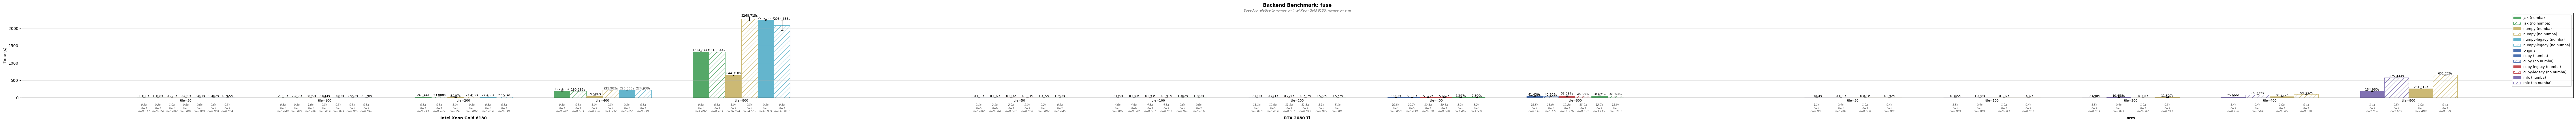

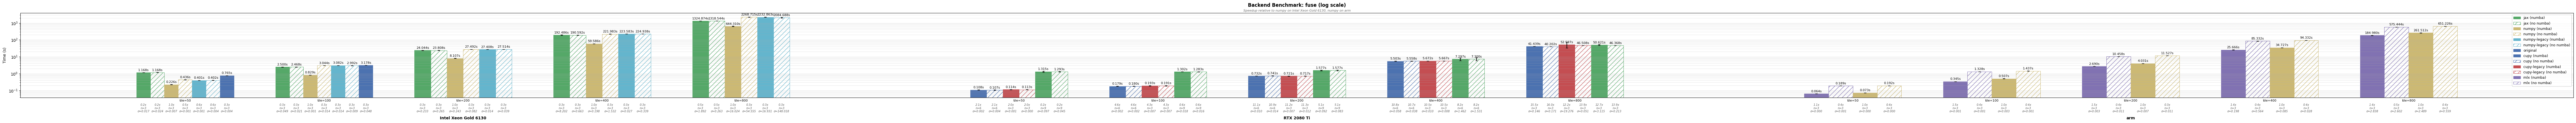

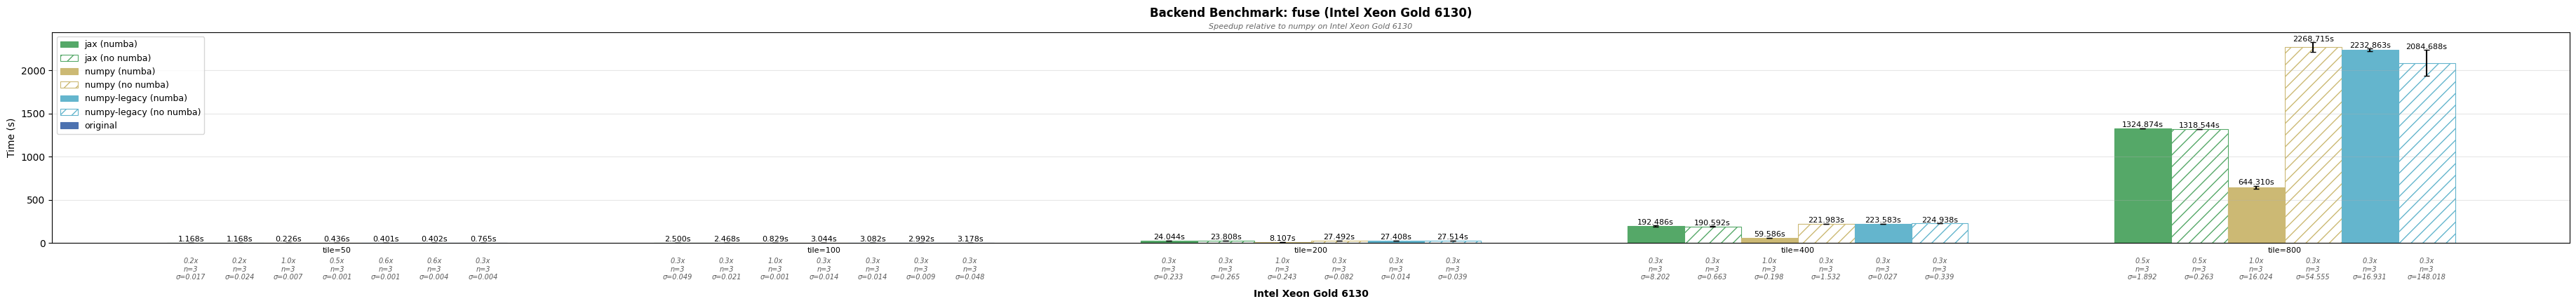

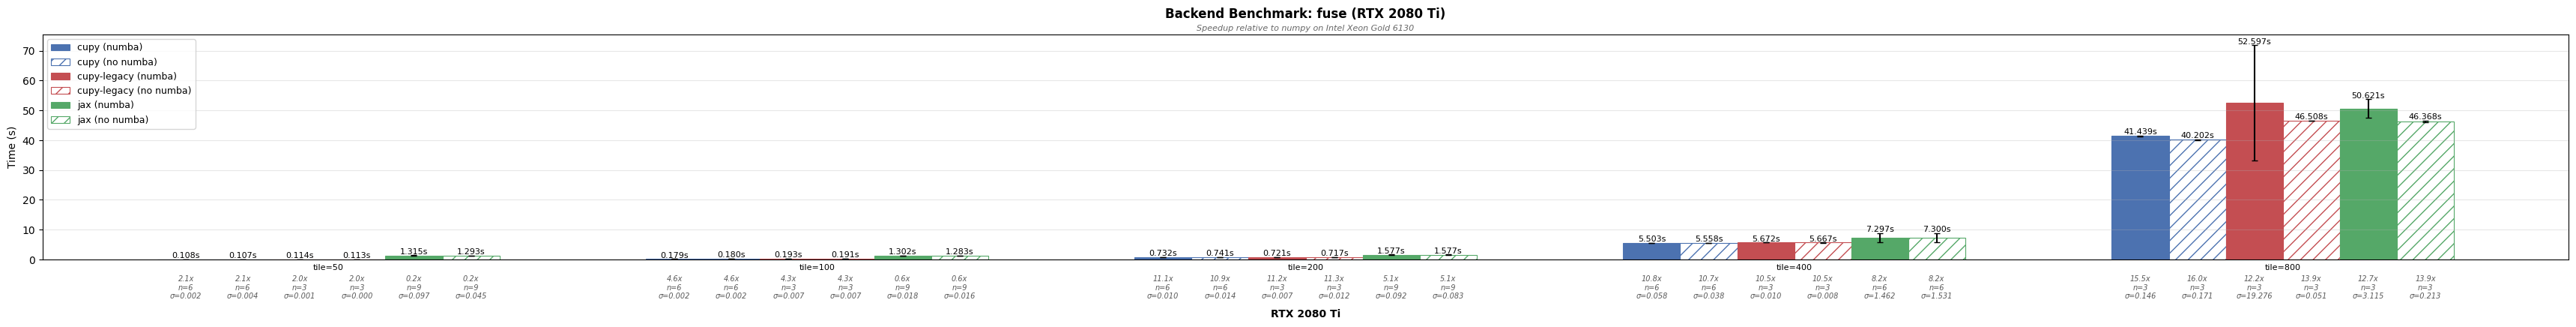

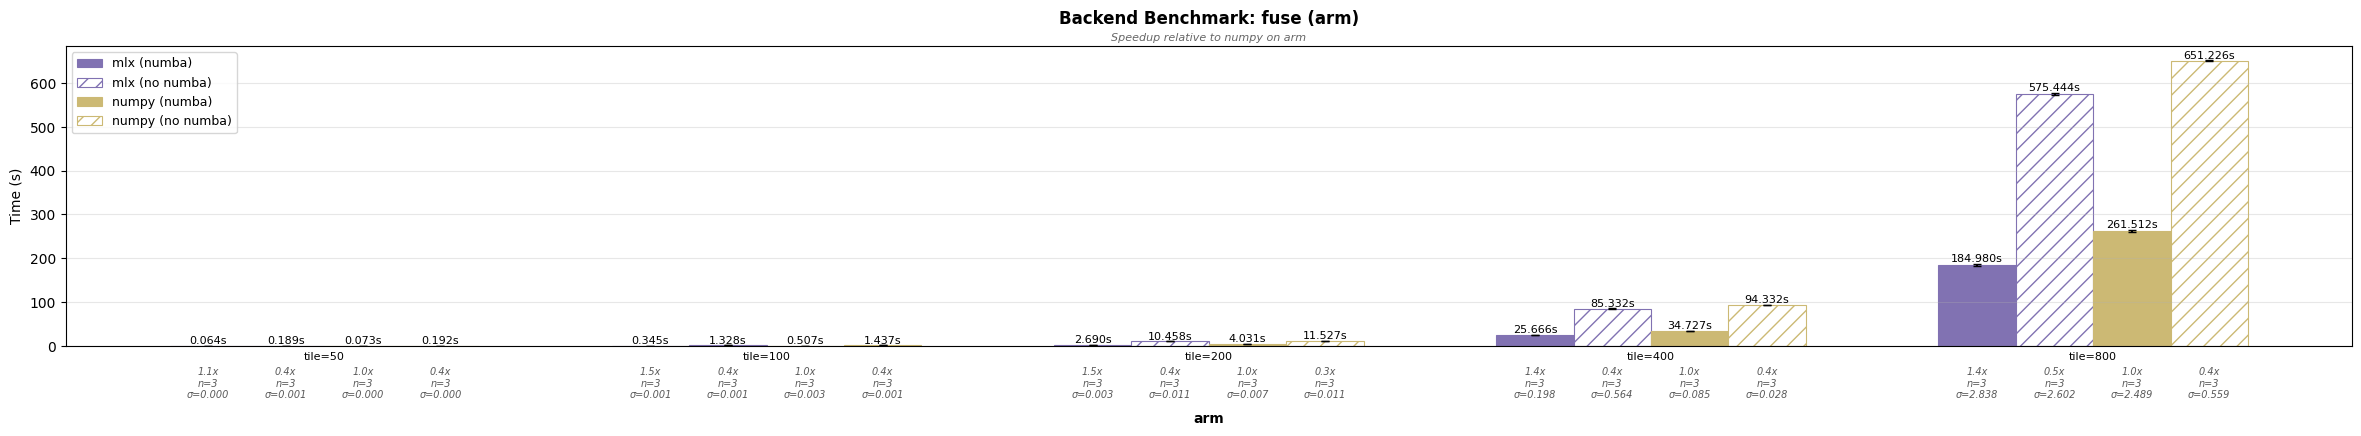

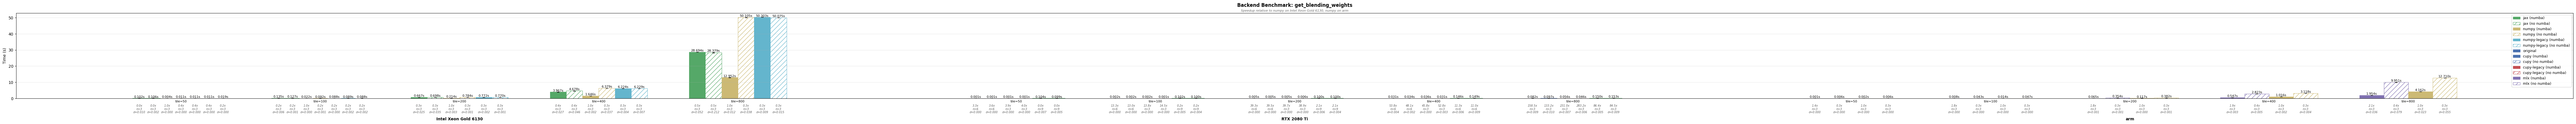

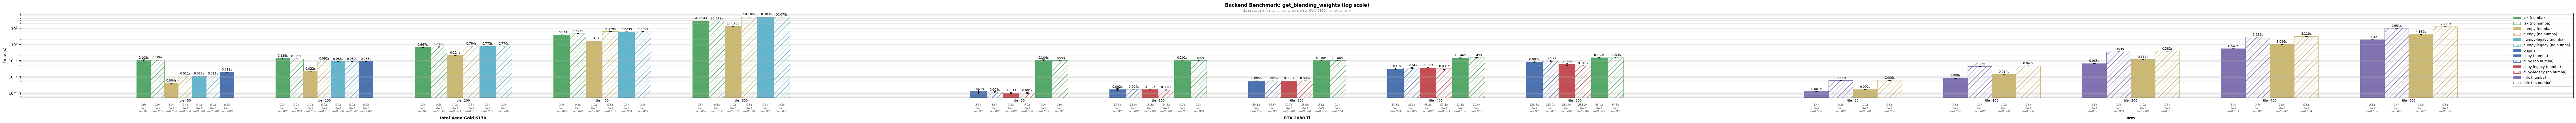

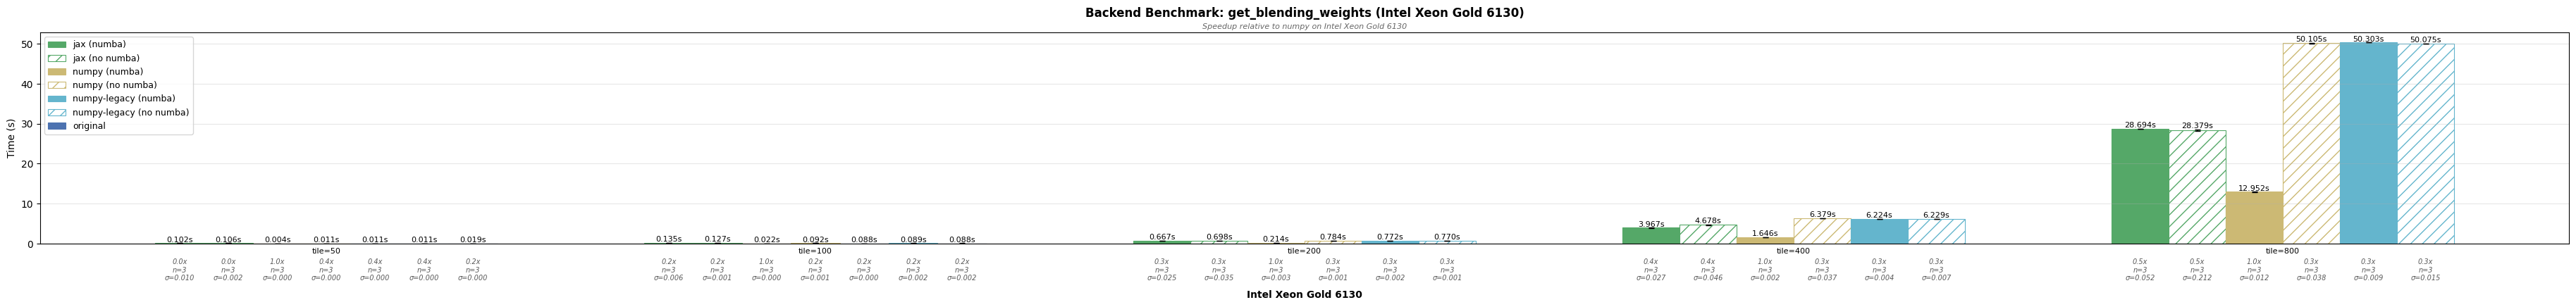

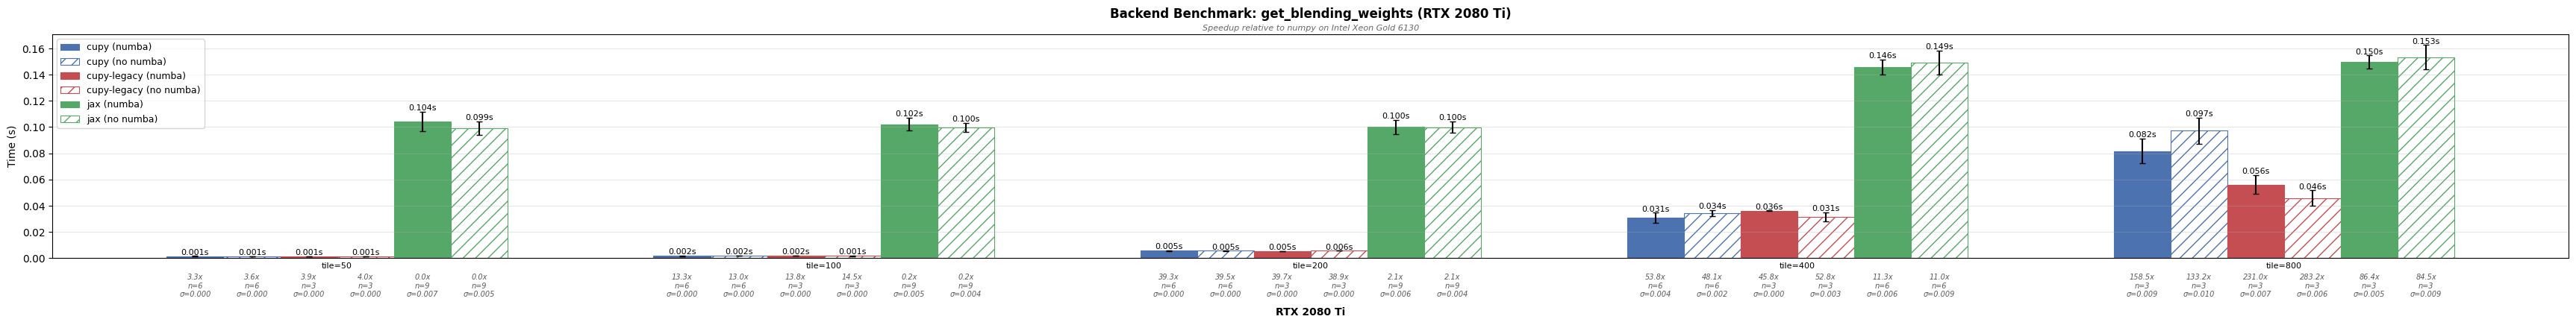

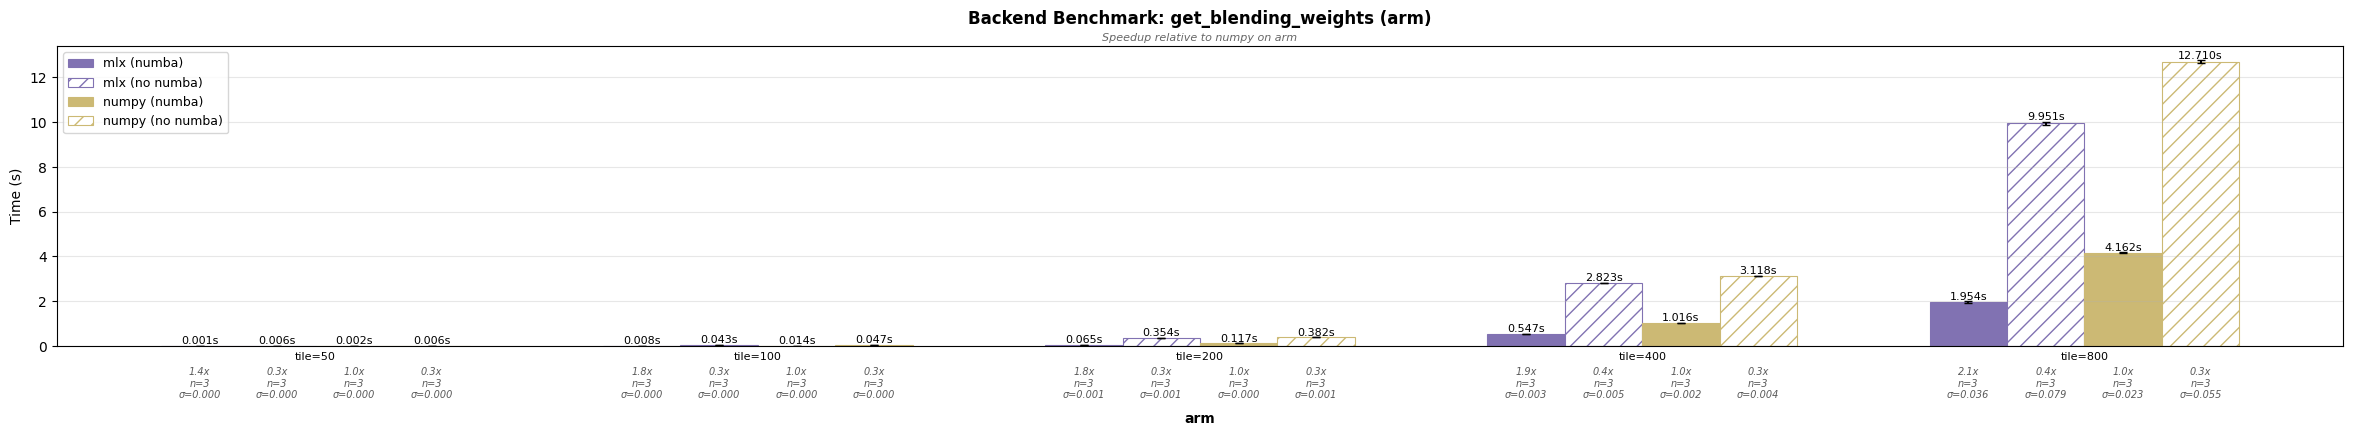

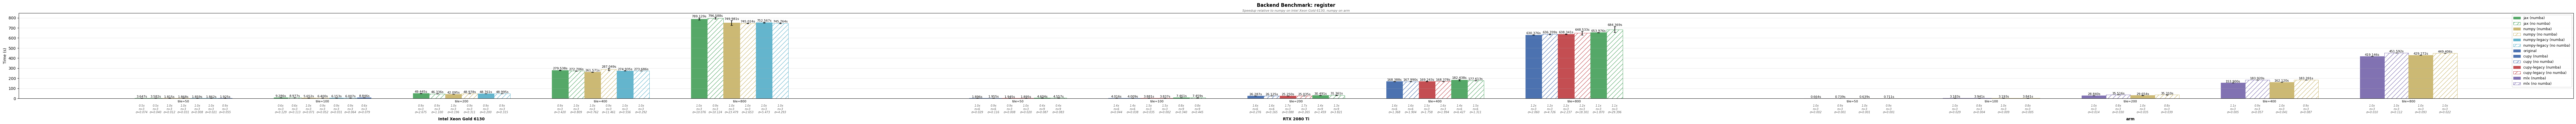

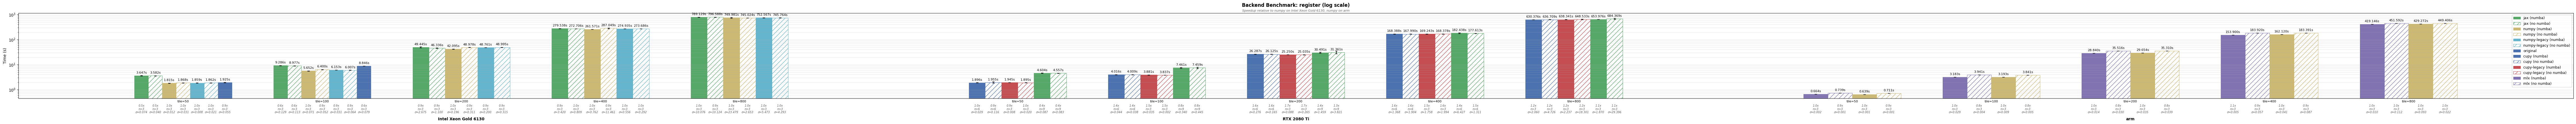

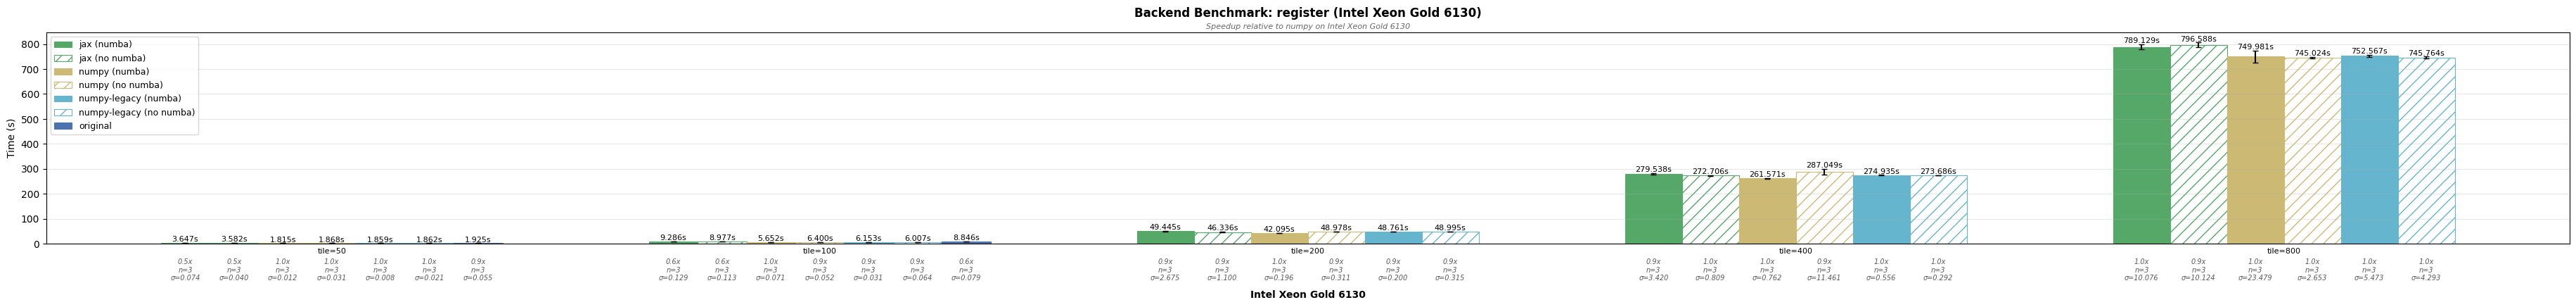

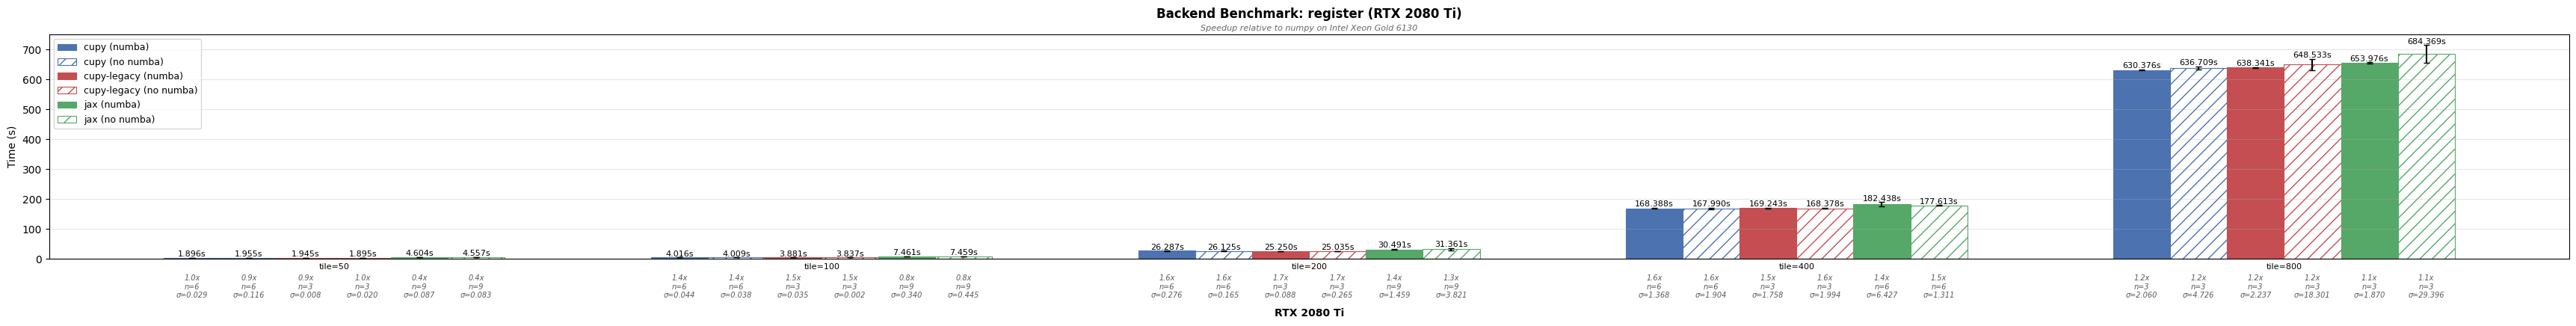

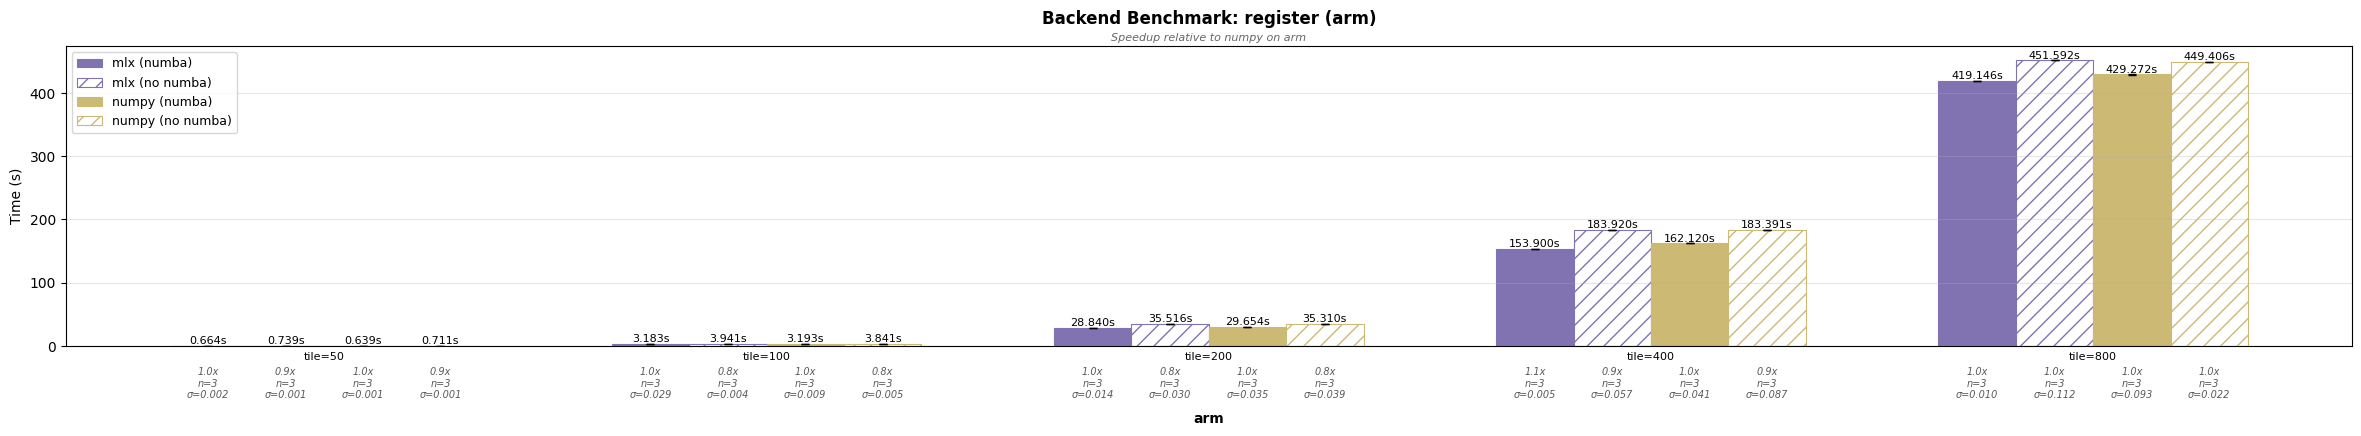

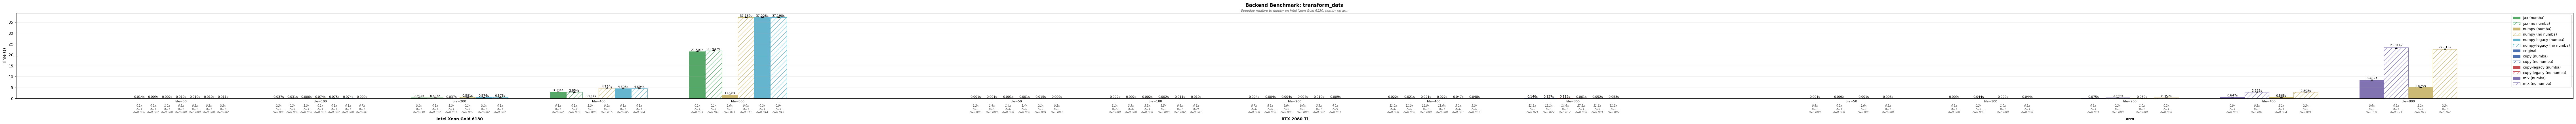

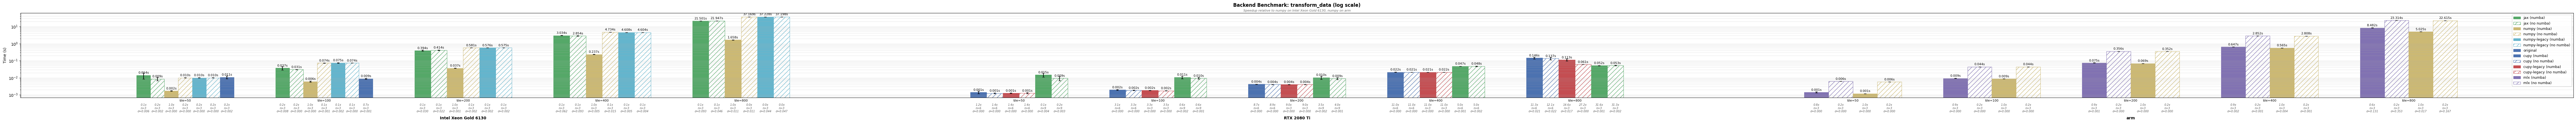

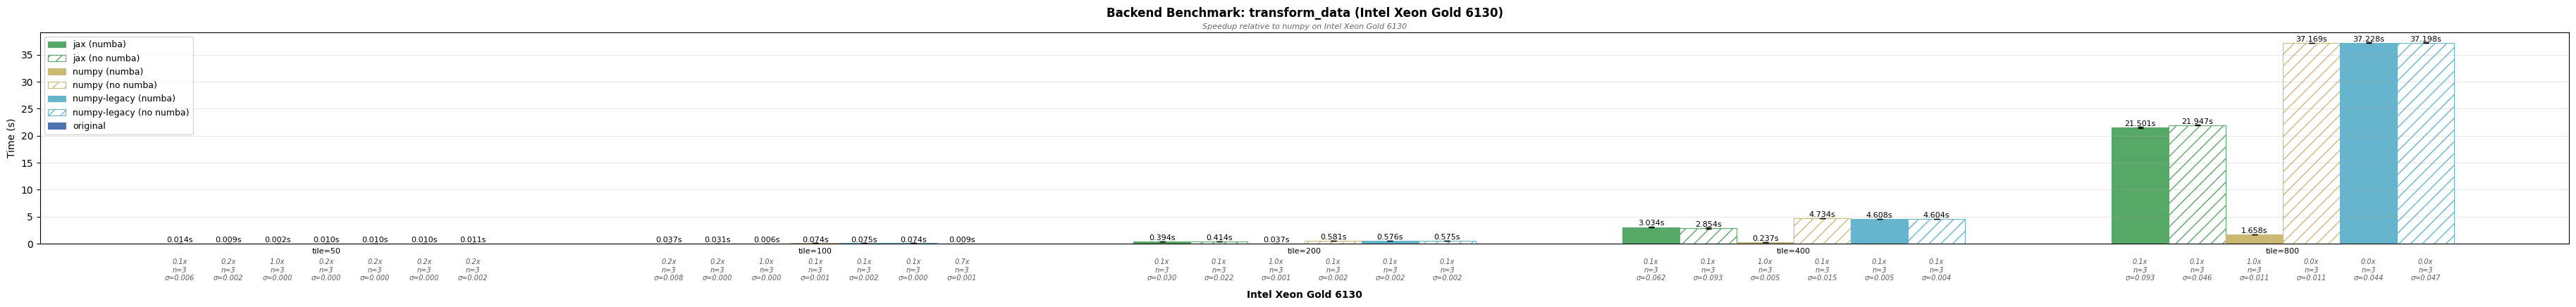

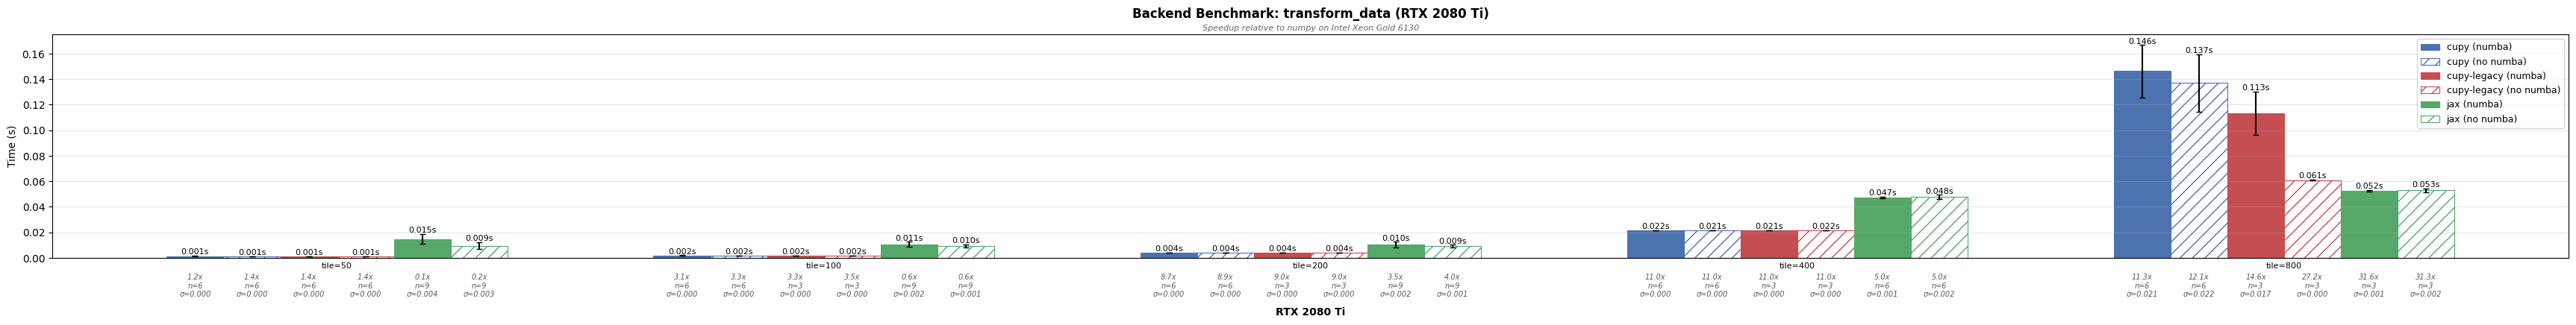

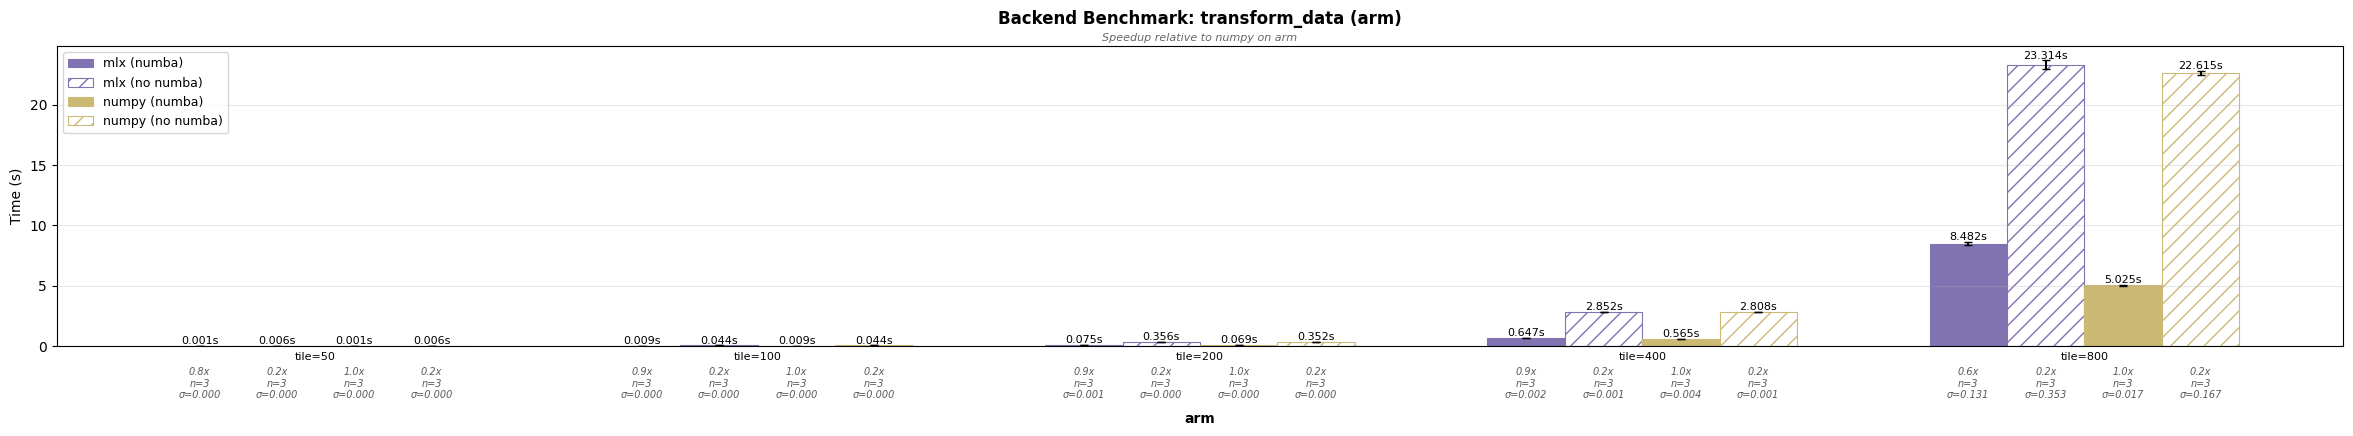

In [4]:
if _HAS_BACKENDS:
    from multiview_stitcher.backends import evaluate_benchmarks, plot_runtime_and_speedup

    merged = evaluate_benchmarks(OUTPUT_DIR)
    figures = plot_runtime_and_speedup(merged)
else:
    print("Evaluation requires the dev version with the backends module.")
    print(f"Results have been saved to: {OUTPUT_DIR}/")
    print()
    print("To view and compare results:")
    print("  1. Install the dev version of multiview-stitcher")
    print("  2. Re-run this cell (sections 1-4 only, no need to re-benchmark)")
    print("  3. evaluate_benchmarks() will load and merge all JSON files,")
    print("     including 'original' results alongside backend results.")

## 5. Tips and notes

**Dask scheduler.** CuPy fusion must use `scheduler="synchronous"` (or
the backend's `recommended_dask_scheduler`). The threaded scheduler causes
GPU memory contention and is actually slower.

**Global default.** Instead of passing `backend=` everywhere, set the
default once:
```python
multiview_stitcher.set_backend("cupy")
# All subsequent calls use CuPy unless overridden
```

**Registration speedup.** Registration operates on small, binned overlap
regions. The GPU speedup is modest unless `cucim` is installed for
GPU-native phase cross-correlation. Fusion benefits most because it
processes the full output volume.

**Custom fusion functions.** User-provided `fusion_func=` callables only
work with the NumPy backend. Built-in functions (`weighted_average_fusion`,
`max_fusion`) work with any backend.

**Memory.** For very large tiles, CuPy may run out of GPU memory. Reduce
`output_chunksize` in `fuse()` or fall back to NumPy for those chunks.